# Module 1 — Introduction to LLMs


## Setup

*these will be present in the beginning of all the notebooks to make sure the environment is setup correctly in Colab*

### Setup Notebook Environment

### Installing Python Libraries

**In Colab**, this might ask you to restart your session, do so and if you face issues that Gemini can't help you with ask the TA.

In [1]:
# ============================================================
# COLAB INSTALL CELL (NO IMPORTS HERE)
# ============================================================

import subprocess

def run(cmd):
    print(f"\n>>> {cmd}\n")
    subprocess.run(cmd, shell=True, check=True)

print("\n================================================")
print("STEP 1: FIX NUMPY (CRITICAL)")
print("================================================\n")

run("pip uninstall -y numpy || true")
run("pip install --no-cache-dir numpy==1.26.4")

print("\n================================================")
print("STEP 2: CORE PACKAGES")
print("================================================\n")

run(
    "pip install -U --no-cache-dir "
    "unsloth ollama "
    "transformers==5.5.0 "
    "chromadb==0.5.5 "
    "posthog==2.5.0"
)

print("\n================================================")
print("STEP 3: SYSTEM DEPENDENCIES")
print("================================================\n")

run("apt-get update -y && apt-get install -y zstd")

print("\n================================================")
print("STEP 4: OLLAMA INSTALL")
print("================================================\n")

run("curl -fsSL https://ollama.com/install.sh | sh")


# SAFE STOP MESSAGE (DO NOT AUTO CRASH)
from IPython.display import display, HTML

display(HTML("""
<div style="padding:16px;border-radius:10px;border:1px solid #ddd;background:#f8f9fa;font-family:Arial">
<h2 style="color:green;">✔ Install Complete</h2>

<p><b>Now you MUST restart runtime:</b></p>
<p>Runtime → Restart session</p>

<p style="color:gray;font-size:13px;">
This is required to fix NumPy / Torch binary compatibility.
</p>
</div>
"""))


STEP 1: FIX NUMPY (CRITICAL)


>>> pip uninstall -y numpy || true


>>> pip install --no-cache-dir numpy==1.26.4


STEP 2: CORE PACKAGES


>>> pip install -U --no-cache-dir unsloth ollama transformers==5.5.0 chromadb==0.5.5 posthog==2.5.0


STEP 3: SYSTEM DEPENDENCIES


>>> apt-get update -y && apt-get install -y zstd


STEP 4: OLLAMA INSTALL


>>> curl -fsSL https://ollama.com/install.sh | sh



Get Ollama (this is what we are using to interact with the model and manage it)

In [1]:
import subprocess
import os
import glob
# ============================================================
# COLAB RUNTIME CELL (IMPORTS ONLY)
# ============================================================

import unsloth
import torch
import transformers

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA Available:", torch.cuda.is_available())

# Ollama is SYSTEM binary, not Python package
import subprocess
print("Ollama installed:", subprocess.run(["which", "ollama"], capture_output=True).returncode == 0)

# ------------------------------------------------------------
# Detect Colab
# ------------------------------------------------------------

try:
    import google.colab
    IN_COLAB = True
    print("Running on Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")


# ------------------------------------------------------------
# HTML helper (ONLY used in Colab)
# ------------------------------------------------------------

def show_status(title, lines, color="#4CAF50"):
    if not IN_COLAB:
        return

    from IPython.display import display, HTML

    html = f"""
    <div style="
        padding:16px;
        border-radius:10px;
        border:1px solid #ddd;
        background:#f9f9f9;
        font-family:Arial;
        margin-top:10px;
    ">
        <h2 style="color:{color}; margin:0;">{title}</h2>
        <ul>
            {''.join(f'<li>{l}</li>' for l in lines)}
        </ul>
    </div>
    """
    display(HTML(html))


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def run(cmd):
    print(f"\n>>> {cmd}\n")
    subprocess.run(cmd, shell=True, check=True)


def is_binary_installed(name: str) -> bool:
    return subprocess.run(
        ["which", name],
        capture_output=True
    ).returncode == 0


# ------------------------------------------------------------
# FIXED: correct course name
# ------------------------------------------------------------

def find_course_dir_gdrive() -> str:

    matches = []

    for m in glob.glob('/content/drive/**/pyproject.toml', recursive=True):

        try:
            with open(m, "r") as f:
                content = f.read()

                if 'applied-language-models-course' in content:
                    matches.append(os.path.dirname(m))

        except Exception:
            pass

    if not matches:
        return input("Enter path to student_scaffolding folder: ")

    return matches[0]


# ------------------------------------------------------------
# Colab setup
# ------------------------------------------------------------

status_lines = []

if IN_COLAB:

    print("\nInstalling system dependencies...\n")
    run("apt-get update -y && apt-get install -y zstd")
    status_lines.append("zstd installed")

    # --------------------------------------------------------
    # Install Ollama
    # --------------------------------------------------------

    if not is_binary_installed("ollama"):
        print("\nInstalling Ollama...\n")
        run("curl -fsSL https://ollama.com/install.sh | sh")
        status_lines.append("Ollama installed")
    else:
        status_lines.append("Ollama already present")


# ------------------------------------------------------------
# Python imports
# ------------------------------------------------------------

import torch
import transformers

try:
    import unsloth
    status_lines.append("Unsloth imported successfully")
except Exception as e:
    status_lines.append(f"Unsloth import failed: {e}")


status_lines.extend([
    f"Torch: {torch.__version__}",
    f"Transformers: {transformers.__version__}",
    f"CUDA Available: {torch.cuda.is_available()}"
])


# ------------------------------------------------------------
# SHOW FINAL STATUS UI
# ------------------------------------------------------------

show_status(
    "✔ Environment Setup Complete",
    status_lines,
    color="#2E7D32"
)


if IN_COLAB and is_binary_installed("ollama"):
    print("\nOllama is installed. Start it with:")
    print("  !ollama serve")
    print("Then use HTTP API on port 11434")

print("\nEnvironment ready.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Torch: 2.10.0+cu128
Transformers: 5.5.0
CUDA Available: True
Ollama installed: True
Running on Google Colab

Installing system dependencies...


>>> apt-get update -y && apt-get install -y zstd




Ollama is installed. Start it with:
  !ollama serve
Then use HTTP API on port 11434

Environment ready.


Getting the data and making sure we are in the right root directory.

There are two recommended ways,
- Upload to drive from your local using "setup assistant"
- Use github with PAT token

While we have tried to accommodate different styles of working there might still be exceptions and ways of doing this that we might have skipped to test.

**Getting the PAT from Github**

[Documentation](https://dev.to/warnerbell/how-to-generate-a-github-personal-access-token-pat-1bg5)

Options:
  - Choose Classic Token
  - Give access to repo

In [2]:
if IN_COLAB:
    import os
    import subprocess
    import zipfile
    import getpass

    # ----------------------------
    # CONFIG
    # ----------------------------
    REPO_URL = "https://github.com/watspeed/language-models.git"
    TARGET_DIR = "/content/repo"

    # Optional: set to None or a branch name
    REPO_BRANCH = None  # or None for main

    # ----------------------------
    # MENU
    # ----------------------------
    print("""
    📦 Project Loader Options:

    1 - Auto (Drive → Git → ZIP)
    2 - Git only
    3 - ZIP upload
    """)

    choice = input("Enter choice (1, 2, 3): ").strip()

    # ----------------------------
    # DRIVE (optional)
    # ----------------------------
    def try_drive():
        try:
            from google.colab import drive
            drive.mount('/content/drive')

            default_path = "/content/drive/MyDrive/watspeed_llm_course"
            if os.path.exists(default_path):
                print(f"📁 Default path found: {default_path}")
                return default_path

            print("🔄 Searching Google Drive...")

            path = find_course_dir_gdrive()  # optional external helper

            if path:
                print(f"📁 Drive found: {path}")
                return path

        except Exception as e:
            print("⚠️ Drive failed:", e)

        return None


    # ----------------------------
    # GIT (MAIN + BRANCH SUPPORT)
    # ----------------------------
    def try_git(repo_url, branch=None):
        try:
            if os.path.exists(TARGET_DIR):
                print("📁 Repo already exists, reusing...")
                return TARGET_DIR

            # default branch = main
            branch = branch or "main"

            print(f"🔄 Cloning repo (branch: {branch})...")

            def run_clone(url):
                return subprocess.run(
                    ["git", "clone", "--branch", branch, "--single-branch", url, TARGET_DIR],
                    text=True,
                    capture_output=True
                )

            # 1) try public clone
            result = run_clone(repo_url)

            if result.returncode == 0:
                return TARGET_DIR

            print("⚠️ Public clone failed. Trying PAT...")

            # 2) PAT fallback
            token = getpass.getpass("🔐 Enter GitHub PAT: ")

            auth_url = repo_url.replace(
                "https://", f"https://{token}:x-oauth-basic@"
            )

            result = run_clone(auth_url)

            if result.returncode == 0:
                return TARGET_DIR

            print("❌ Git clone failed")
            print(result.stderr)
            return None

        except Exception as e:
            print("⚠️ Git error:", e)
            return None


    # ----------------------------
    # ZIP IMPORT
    # ----------------------------
    def try_zip():
        print("📦 Upload ZIP...")
        from google.colab import files

        uploaded = files.upload()
        if not uploaded:
            print("⚠️ No file uploaded")
            return None

        zip_file = list(uploaded.keys())[0]

        try:
            with zipfile.ZipFile(zip_file, 'r') as z:
                z.extractall("/content")
        except zipfile.BadZipFile:
            print("❌ Invalid ZIP file")
            return None

        folder = zip_file.replace(".zip", "")
        path = os.path.join("/content", folder)

        print(f"📁 Extracted: {path}")
        return path


    # ----------------------------
    # MAIN LOGIC
    # ----------------------------
    project_path = None

    if choice == "2":
        project_path = try_git(REPO_URL, REPO_BRANCH)

    elif choice == "3":
        project_path = try_zip()

    else:
        # AUTO MODE
        project_path = try_drive()

        if not project_path:
            project_path = try_git(REPO_URL, REPO_BRANCH)

        if not project_path:
            project_path = try_zip()


    # ----------------------------
    # FINAL STEP
    # ----------------------------
    if project_path and os.path.exists(project_path):
        try:
            os.chdir(project_path)
            print("✅ Active directory:", os.getcwd())
            print("📂 Contents:", os.listdir())
        except Exception as e:
            print("❌ Failed to switch directory:", e)
    else:
        print("❌ No project loaded")

else:
    def in_root_folder() -> bool:
        return os.path.isdir("notebooks") and os.path.isdir("data")

    if not in_root_folder():
        import os
        os.chdir("..")



    📦 Project Loader Options:

    1 - Auto (Drive → Git → ZIP)
    2 - Git only
    3 - ZIP upload
    
Enter choice (1, 2, 3): 2
🔄 Cloning repo (branch: main)...
⚠️ Public clone failed. Trying PAT...
🔐 Enter GitHub PAT: ··········
✅ Active directory: /content/repo
📂 Contents: ['.gitignore', 'deploy_to_hf.py', 'src', '.claude', 'data', 'prompts', '.python-version', 'uv.lock', 'project_structure.md', 'notebooks', '.git', 'upload_to_colab.sh', 'pyproject.toml', 'course_setup.md', 'notebook_image_catalogue.md', 'CLAUDE.md', 'README.md']


In [3]:
from IPython.display import display, Markdown

### Start Ollama and Load the Model

In [4]:
if IN_COLAB:
    import subprocess, time
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(3)  # give it a moment to start

!ollama pull gemma2:2b

In [5]:
import ollama
response = ollama.generate(
    model="gemma2:2b",
    prompt="hi, who is out there?"
)
text = response.response.strip()

print(text)

Hello! 👋 

It's me, Gemma. I'm an AI assistant here to help with any questions or tasks you might have. 😊  What can I do for you today?


---

## What Is a LLM?

A "large" language model or a language model whether mini, small/smol or large is a **probabilistic model** that predicts the next token.


The above code that we used using Ollama is an inference engine that takes distribution from the language model called *gemma2:2b* and picks the next token/token from the distribution of possible next words that the model gave and returns the response back to the LLM for it to generate the next token until a special token known as the `EndToken` is generated

Similarly, ChatGPT or Claude etc. that we use on the web are applications that run this loop and other magic sauce that we will cover later on, but coming back to the next token generation you can look under the hood in Ollama by inspecting something known as `LogProbs`

We can ask the LLM itself for an explanation of LogProbs,

In [6]:
result = ollama.generate(
    model="gemma2:2b",
    prompt="What is a logprob in LLMs? ELI5",
    top_logprobs=5,
    logprobs=True
)

display(Markdown(result.response))

Imagine you have a big box of LEGO bricks, but there's only one rule: build something that sounds like a cat! 

Now, you want to figure out which combination of bricks (which language) will make the best "meow" sound. 

**Log probability is a tool for measuring how likely different combinations of bricks are.** It's a bit like how we sometimes use math to compare the number of stars in different pictures.

Here's the breakdown:

1. **Probability:** We assign a score to each combination of bricks (each language model's "meow").  A high score means the combination is more likely to make a good meow, and a low score means it's less likely.
2. **Logarithm:** Then, we take the logarithm of these probabilities. It makes them easier to compare!  Think about how you can zoom in or out on a map - the log helps us see things in a different way.
3. **"Log probability":** We look at the result and choose the combination that gives the highest "log probability" score. 

So, in short, **Log probability is a way to compare how likely different language model outputs are to make sense.** It tells us which combination of words or sentences is most "likely" to be a good meow!


**Why is it useful for LLMs?**

LLMs (Large Language Models) try to create language that sounds realistic and makes sense. Log probability helps them do this by: 
* **Finding the best way to express ideas:**  It allows the model to learn which words or phrases are most likely to result in a good meow! 
* **Generating creative text:** The log probability is used to guide the language model towards more interesting and unique outputs.

So, it's like a detective for language! It helps LLMs solve puzzles and create fun, meaningful content.

### Let's Dive a Bit Deeper in the Code and Response Above,

In the diagram below you can see a visual representation of what happens under the hood when we inference over *gemma2:2b* using Ollama, conceptually this is also the same process happening in all applications of LLMs at the lowest level

![ A sequence of already-generated tokens (e.g. Imagine you have a), with  probability distribution bar chart above the next position showing the top candidate tokens (e.g. 'bunch': 0.98, 'lot': 0.01, …). An arrow highlights the chosen token. Shows that the model assigns a probability to every possible next token and samples from that distribution not that it 'knows' the answer](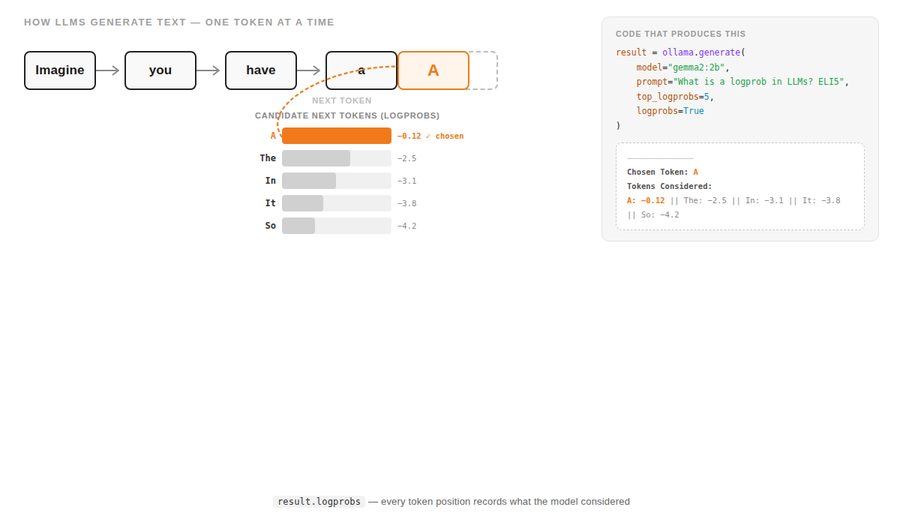)
> **[Diagram Caption]** Three already-generated tokens ("Imagine you have") sit in a left-to-right chain leading to "a" (highlighted in orange) as the current position. A bar chart below lists five candidate next tokens with their log-probability scores: A (−0.12, chosen and highlighted in orange), The (−2.5), In (−3.1), It (−3.8), So (−4.2). A code panel on the right shows the ollama.generate call with logprobs=True that produced this output; a "Chosen Token: A" summary box lists all five candidates numerically. The caption at the bottom reads "result.logprobs — every token position records what the model considered."


Since we enabled `logprobs=True` and asked for 5 with `top_logprobs=5` we can also look at the `results` and see what those logprobs were

In [7]:
def print_log_prob(log_prob_object):
    print("-" * 10)
    print("Chosen Token: **", log_prob_object.token, "**")
    print("Tokens Considered: \n", " || ".join([f"{log_prob.token}: {round(log_prob.logprob, 3)}" for log_prob in log_prob_object.top_logprobs]))


# you can change the range here to see what happens, feel free to break this :)
log_prob_range = 5
print("Sentence: ", "".join([prob.token for prob in result.logprobs[:log_prob_range]]))

for logprob in result.logprobs[:log_prob_range]:
    print_log_prob(logprob)

Sentence:  Imagine you have a big
----------
Chosen Token: ** Imagine **
Tokens Considered: 
 Imagine: -0.02 || Let: -4.957 || Think: -5.137 ||  Imagine: -6.098 || You: -6.106
----------
Chosen Token: **  you **
Tokens Considered: 
  you: -0.03 ||  a: -4.692 ||  an: -4.902 ||  LL: -5.397 ||  we: -6.135
----------
Chosen Token: **  have **
Tokens Considered: 
  have: -0.625 || ': -0.822 ||  want: -4.026 ||  are: -6.492 ||  and: -6.826
----------
Chosen Token: **  a **
Tokens Considered: 
  a: -0.017 ||  an: -5.058 ||  lots: -6.118 ||  millions: -6.806 ||  many: -6.988
----------
Chosen Token: **  big **
Tokens Considered: 
  big: -0.901 ||  bunch: -1.759 ||  giant: -2.154 ||  huge: -2.307 ||  box: -3.252


---
## Building Intuition on Next Token Prediction

Let's take another example, consider the phrase below:

"The Space is large and vast ____"

and write a completion you can be as creative as you want, there is no right answer ;)

In [8]:
phrase = "The Space is large and vast"
completion = input()

phrase + completion

, darkness


'The Space is large and vast, darkness'

What happens if I add one another line

"As an architect" or "Hey I know you are an expert in astrophysics, can you ..."

LLMs are prone to the same context change as we are, example,

In [9]:
ollama.generate(
    model="gemma2:2b",
    prompt="The Space is large and vast  ___",
    system="Complete the phrase imaginiging you are an astronaut"
).response

'The Space is large and vast **and yet, a tiny human vessel holds the dreams of humanity within its depths.** \n'

**Exercise 1.1** It's your turn to set the context

In [11]:
role = input()
ollama.generate(
    model="gemma2:2b",
    prompt="The Space is large and vast  ___",
    system=f"Complete the phrase imaginiging you are an {role}"
).response

clown


"Here are a few ways to complete the phrase, imagining you're a clown:\n\n**Funny & Silly:**\n\n* The space is large and **vvast**, like a bouncy house for clowns! 🤪\n* The space is **gigantic** and there's lots of room to bounce around! 😄\n\n**Whimsical & Imaginative:**\n\n* The space is **filled with twinkle stars** and a **rainbow waterfall!** ✨🌈\n* The space is so big, it stretches **forever like the sky on a carnival day!** 🎈\n\n\nWhich option do you like best?  Let me know if you want to continue exploring the clown's perspective of the vastness! 😄  🤡\n"

Given certain context , i.e., the prompt and the system prompt the distribution of text that the LLM predicts from changes and that gives us flexibility to tackle multiple different problems from a single model, not without challenges or drawbacks though.

**Flexibility**
Since I can define my prompt to force the LLM to pick words from a particular distribution I can make it do multiple things
- "Hey I am doing research on the topic of what is an LLM, I don't really understand what are logprobs. I just think it's a super weird name can you help me understand it please."
- "How do I write this in French, I want to just tell the person that I am really busy at the moment!!."
- "I need help choosing my beard style"

With just next token prediction we are able to use the same model and have the possibility to do so much more, that companies are betting billions just to stay ahead in this race.

But, the grass is not all green.

**Challenges**
The catch is that human communication relies on context in ways the model cannot automatically resolve:
- We speak in context
- The context is gathered from
    - our past experience
    - who we are talking to
    - what we are aiming to achieve etc.
- LLMs don't validate what they are saying. (sorry they are not intelligent beings, someday maybe but not today)

## Building Applications with LLMs

An LLM application is something built on top of an LLM — it takes the next-token prediction behavior and wraps it into something useful. In the course we will work with a recipes dataset to showcase different aspects of LLM applications. The image below schematically shows the layers of building a recipe classifier using LLMs.

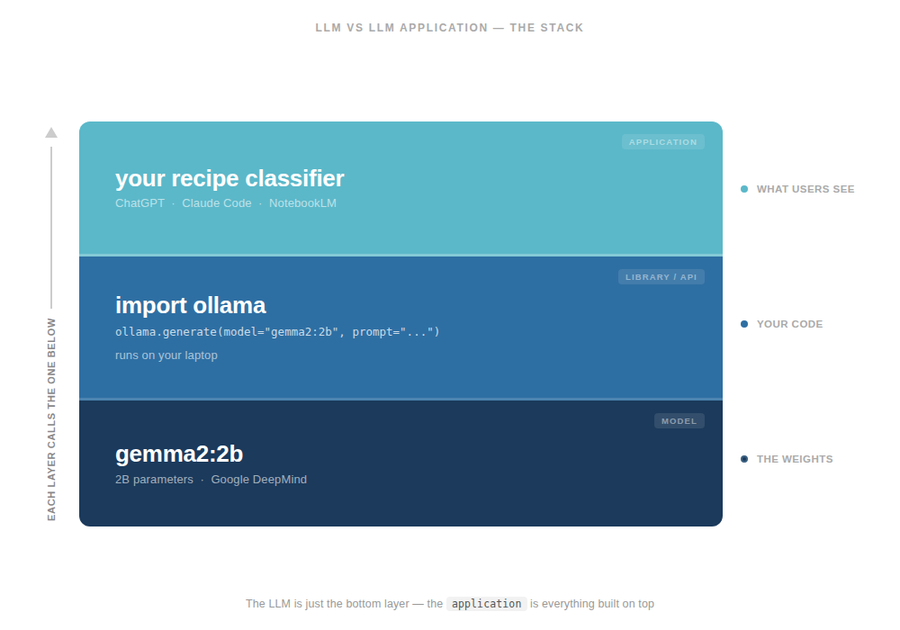

> **[Diagram Caption]** Three stacked horizontal bands inside a diagram titled "LLM VS LLM APPLICATION — THE STACK." Bottom band (dark navy, "MODEL / THE WEIGHTS"): gemma2:2b, 2B parameters, Google DeepMind. Middle band (medium blue, "LIBRARY / API / YOUR CODE"): import ollama, ollama.generate(model="gemma2:2b", prompt="..."), runs on your laptop. Top band (teal, "APPLICATION / WHAT USERS SEE"): your recipe classifier, alongside ChatGPT · Claude Code · NotebookLM. A vertical label on the left reads "EACH LAYER CALLS THE ONE BELOW." The tagline at the bottom reads "The LLM is just the bottom layer — the application is everything built on top."

Examples of LLM applications you've probably heard of are:
  - `ChatGPT`
  - `Claude Code`
  - `NotebookLM`

These took millions of dollars and large teams to build. But just like in software, there is a whole spectrum — and on the simpler end, *a single well-crafted prompt call is already an application*. A script that labels support tickets, picks a recipe based on what's in your fridge, or rewrites a product description is an LLM application.

That's what you'll build in this course — starting right below.

---
## Let's Dive into Recipes

The dataset is available at [data/](../data/All_Recipe_Web_Scraping_Dataset_Labeled.csv) along with your material so that you are able to run your notebooks on Colab or locally.

In [12]:
import pandas as pd


recipes = pd.read_csv("data/All_Recipe_Web_Scraping_Dataset_Labeled.csv")

recipes.columns

Index(['Name', 'Rating', 'Description', 'Prep Time', 'Cook Time', 'Total Time',
       'Servings', 'Ingredients', 'Image URL', 'prep_mins', 'cook_mins',
       'total_mins', 'wait_mins', 'Category Code', 'Category Name',
       'Category Description'],
      dtype='object')

In [13]:
recipes["Name"].head(5).to_list()

['Chicken Souvlaki with Tzatziki Sauce',
 'Bacon-Wrapped Cherries',
 'Meatless Mincemeat Pie',
 'Vegetable Quesadillas',
 "Dad's Lima Bean Soup with Ham Bone"]

---
Let's go through in ways we can interact with the dataset using LLMs

### Use Case 1: Classification

> *"I want to choose from a list of easy recipes what I can cook today."*


In [14]:
import json


result = ollama.generate(
    model="gemma2:2b",
    prompt="""
    Pick me a recipe from the following recipes that I can cook in the evening, I am in mood for something comforting

    'Chicken Souvlaki with Tzatziki Sauce',
    'Bacon-Wrapped Cherries',
    'Meatless Mincemeat Pie',
    'Vegetable Quesadillas',
    "Dad's Lima Bean Soup with Ham Bone"

    and give a reasoning that makes me want to cook it

    Return your answer as JSON with this exact schema:
    {"recipe": "<recipe name>", "reasoning": "<why I should cook it>"}
    """,
    # this helps limit the amount of text you are going to get
    format='json'
)

json.loads(result.response)

{'recipe': "Dad's Lima Bean Soup with Ham Bone",
 'reasoning': "There's nothing quite like a warm bowl of hearty soup on a chilly evening. This recipe combines the comforting flavors of lima beans and ham bone for a classic, soul-satisfying meal. The aroma alone will transport you to cozy evenings, guaranteed to make your evening feel extra special."}

---

### Use Case 2: Decision-Making

> *"I am trying to go vegetarian for the environment!"*


In [15]:
# try hardcode/non or any other
severity = input()
result = ollama.generate(
    model="gemma2:2b",
    prompt=f"""
        I am a {severity} vegetarian can you give instructions on how to replace chicken from the
        'Chicken Souvlaki with Tzatziki Sauce' recipe
    """
)

display(Markdown(result.response))

pure


You absolutely can create delicious "chicken souvlaki" substitutes for your vegetarian diet! Here's how to approach it, combining flavors and textures:

**1. Choosing Your Protein:**

* **Tofu:** Crumbled firm tofu (marinated) is a fantastic choice as it mimics the texture of chicken pieces well. 
    * For extra "bite," consider grilling or baking marinated tofu before adding to your dish.  
* **Mushrooms:** Earthy button mushrooms grilled or pan-fried, or even portobello mushrooms for larger chunks, offer a meaty alternative. 
* **Seitan:** This wheat protein offers a more chewy texture that can be sliced and cooked like chicken pieces.  
    * Seitan is often used in vegetarian dishes as it holds its shape well after cooking.  

**2. Flavoring and Texture: The Key to Success!**

* **Marinade Magic:** For all your substitutes, the key is a great marinade! Experiment with these options:
    * **Lemon & Herb:** This classic works wonders for tofu or mushrooms. Add lemon juice, garlic, oregano, thyme, and olive oil for brightness. 
    * **Ginger-Soy:**  Combine soy sauce, ginger, garlic, sesame oil, and a touch of red pepper flakes for a more savory flavor.   
* **Cooking Methods:**  Use a grilling technique, sautéing, or baking to create texture variety. This mimics how chicken is cooked in souvlaki:

    * **Grilled:** Lightly oiled tofu/mushrooms on a grill for a smoky char and crispy exterior. 
    * **Pan-Fried:** Mushrooms with sliced onions or peppers add more dimension to the dish, while seitan can be pan-fried to a satisfying crispiness.  


**3.  Recipe Adjustments for Souvlaki Inspiration**

Remember that souvlaki often features:

* **Tzatziki Sauce:** Use plain yogurt (Greek yogurt) as the base, and then add chopped cucumber, fresh dill, garlic, lemon juice, and salt and pepper to taste. 
* **Pita Bread:** This is essential for traditional Souvlaki! You can use flatbreads or wrap your substitute with lettuce or a vegetable "wrap" for a lighter option.

**Example Recipe (Tofu-based):**

1. **Marinate the Tofu:** Combine ½ cup of soy sauce, 1 tablespoon of olive oil, 1 tablespoon lemon juice, and ½ teaspoon garlic powder. Marinate tofu cubes for at least 30 minutes in the fridge.
2. **Grilled to Perfection:** Heat a grill pan or outdoor grill over medium heat. Place marinated tofu on a lightly oiled grill rack (or use baking sheet lined with parchment paper) for about 5-7 minutes per side, until golden brown and slightly firm.  
3. **Serve it Up!** Serve the grilled tofu with your tzatziki sauce and toasted pita bread.

**Remember:** Experiment with different combinations to find what you enjoy most!   The world of vegetarian "souvlaki" is vast – get creative in the kitchen! 


Let me know if you want specific recipes or recipe variations based on your chosen protein!  


**Stop (Warning)**

> Given LLMs are throwing out words from a probability distribution, they can seem like pathological liars and they do it with confidence
>and they love smileys :)

---

### Use Case 3: Creation

> *"Can I mix recipes to create a new one?"*


In [16]:
result = ollama.generate(
    model="gemma2:2b",
    prompt="""
        how can I mix the recipes of
        - 'Chicken Souvlaki with Tzatziki Sauce'
        - 'Bacon-Wrapped Cherries',
        - 'Meatless Mincemeat Pie',
    """,
    system="You are a culinary chef exploring the depths of taste"
)

display(Markdown(result.response))

This is a fantastically ambitious culinary challenge! You're aiming for a blend of savory, sweet, and comforting flavors.  Let's dive into how to "mix" these recipes, keeping in mind the core ingredients and their potential transformations:

**Understanding the Ingredients & Flavors:**

* **Chicken Souvlaki with Tzatziki Sauce:** We've got: 
    * **Flavor Focus:** Mediterranean-inspired; Think herbs, lemon, garlic, and a touch of smokiness.  
    * **Meat:** Chicken (shredded or diced).  
    * **Sauce:** Tzatziki—yogurt, cucumber, dill, and lemon – provides cool, fresh contrast to the meat's richness.

* **Bacon-Wrapped Cherries:** A symphony of sweet and salty: 
    * **Flavor Focus:** Classic combination; bacon adds smoky depth, while cherries provide a juicy sweetness.  
    * **Meat:** Bacon (cooked and crumbled). 
    * **Fruit:** Cherries – we'll likely want to roast these for extra depth in flavor before wrapping them.

* **Meatless Mincemeat Pie:** A holiday staple, this recipe brings us warmth and comfort through hearty autumn flavors:
    * **Flavor Focus:** Warm spices, dried fruits (cranberries, raisins), nuts (pecans or walnuts), and a touch of ginger for complexity. 
    * **Meat:**  The "mince" aspect is replaced by mashed root vegetables. The pie itself will likely have a pastry crust.

**Mixing the Recipes – Ideas & Possibilities:**

1. **"Mediterranean-Inspired Dessert":**
   * **Concept:**  Transform the cherries from the bacon-wrapped dessert into a refreshing, sweet-and-savory part of your main course. 
   * **Execution:** 
       * Roast cherries with chopped almonds and rosemary for added complexity (a hint of smoke).
       * Create a creamy sauce by combining tzatziki with a touch of honey to balance the tangy yogurt and sweet roasted cherry.  
       * Top the souvlaki skewers with this cherry-tzatziki topping, bringing together the Mediterranean essence of these flavors.

2. **"Hearty Autumn Comfort":**
    * **Concept:** The savory side elements from your souvlaki (chicken, spices) could be used to create a flavorful filling for the meatless pie. 
    * **Execution:** 
       *  Mix shredded chicken and diced onion with your mincemeat base, adding herbs and dried fruits. 
        * The combination of warm spices, nuts, and the savory element would complement the pies’ sweet components perfectly.

**Important Considerations for Mixing Recipes:**

* **Balance & Harmony:** Ensure there's a balance between sweet and salty (from bacon to cherry). 
* **Texture Contrast:**  Aim for varying textures – crispy bacon, juicy cherries, hearty pie crust.
* **Seasonal Flavors:** Consider using seasonal ingredients; fresh herbs, seasonal fruits will enhance your final dish.
* **Visual Appeal:** A beautifully arranged plate with an interplay of colors (red cherry, golden pastry, green herb). 


Let me know what you're most interested in trying first – the pie or dessert? We can further brainstorm and explore specific recipes to bring your culinary "deep dive" to life!  


---
# How Does an LLM "know" Stuff

Reminder the LLM is just predicting the next token, so how does it accumulate so much "knowledge"?


The LLM manipulates what we call "tokens": these are like words but broken down further to allow us to cover the breadth of language without a vocabulary explosion, (we will cover this in more details in Module 2).

These tokens travel through the neural network (a chain of functions that output numbers) in an architecture called Transformers. During training, the model predicts the next token and a loss function (cross-entropy) measures how far off the prediction was. The gradient of this loss guides the model toward "understanding" the relationships between tokens at syntax, semantics, and even more nuanced layers of reasoning. Most LLMs are training on the majority of text available on the internet as well as curated data collected by their creators. This means that they have access to a large amount of knowledge sources and with enough training time can "intuit" the nuanced relationships present in natural language.

At a high level, transformers can generalize, given
- enough time,
- enough data, and
- a good validation dataset

**Supplementary Exercise: Understanding in depth transformers and early GPT models**
- [A great visual representation of GPT models](https://bbycroft.net/llm)
- Transformers
    - [3Blue1Brown's](https://www.youtube.com/watch?v=wjZofJX0v4M) — visual, intuitive
    - [Jay Alammar's](https://jalammar.github.io/illustrated-transformer/) — excellent diagrams

----


# How Gemma2 Series Models Are Built


## Gemma 2B — The Model You've Been Running

Gemma is a Google DeepMind model, built on the same research as their Gemini series. The key difference: Gemma is open weights — the model file is public, which is why Ollama can run it on your laptop without an API key or account.

The "2B" means 2 billion parameters — roughly. (The real count is closer to 2.5B when you include vocabulary embeddings, but close enough.) Think of these as the numbers the model learned during training — everything it can do is encoded in them. More parameters = more capable, but also slower and heavier. `gemma2:2b` is small enough to run locally, and that's the tradeoff we made for this course.

It was trained on 3 trillion tokens — mainly English web text, maths, and code. Google hasn't published the exact breakdown, just the categories. For scale: 3 trillion tokens is roughly 30 million books (at ~80–100k tokens per book).

And it wasn't cheap. Pre-training alone needed 512 Google TPU chips running in parallel and emitted ~131 tonnes of CO₂ — roughly 50 transatlantic flights. This is why we use a pre-trained model: the expensive part is already done.

Worth knowing: pre-training alone produces a model that *continues text* — it just predicts the next token. The [fine-tuning and RLHF](https://arxiv.org/abs/2203.02155) phases are what turn that into something that actually follows your instructions.

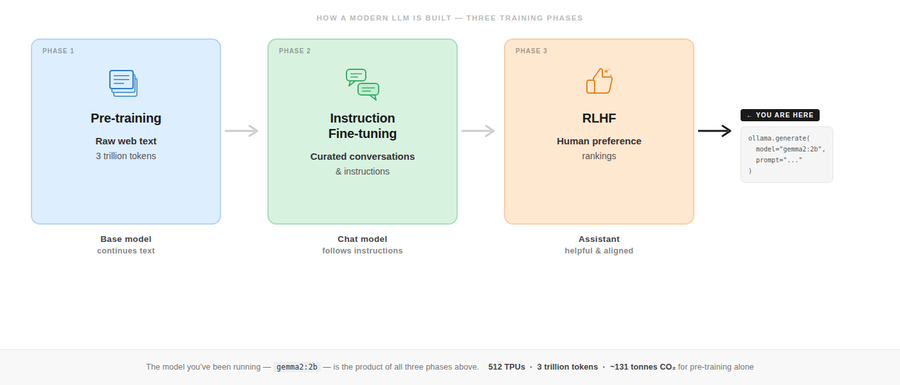
> **[Diagram Caption]** Three sequential training-phase boxes with arrows between them, titled "HOW A MODERN LLM IS BUILT — THREE TRAINING PHASES." Phase 1 (blue, document icon): Pre-training, raw web text, 3 trillion tokens → output: base model, continues text. Phase 2 (green, speech-bubble icon): Instruction Fine-tuning, curated conversations & instructions → output: chat model, follows instructions. Phase 3 (peach, thumbs-up icon): RLHF, human preference rankings → output: assistant, helpful & aligned. A bold arrow leads to a terminal "YOU ARE HERE" box showing the ollama.generate call. The footnote reads "The model you've been running — gemma2:2b — is the product of all three phases above. 512 TPUs · 3 trillion tokens · ~131 tonnes CO₂ for pre-training alone."


---

**So what can it actually do?**

The model's strengths and limits come directly from what it saw in training.

| Task | Reliability with `gemma2:2b` |
|---|---|
| Summarising, rewriting, classifying | Generally reliable |
| Common-sense reasoning | Mostly reliable |
| Niche domains (medical, legal, proprietary) | Less reliable — may hallucinate |
| Events after the training cutoff | Not available |
| Complex multi-step arithmetic | Unreliable at 2B scale |

A useful question before scoping any use case:
> *"Could a well-read generalist do this with the context I give them?"*  
> If yes — a well-prompted LLM probably can too.

---

---

## Key Takeaways

Everything in this module connects back to one mechanism: an LLM predicts the next token by sampling from a learned probability distribution over its vocabulary. The prompt — system message plus user input — shifts that distribution, which is what gives us control. A few things worth holding onto as you move into the rest of the course:

- **Next-token prediction is the whole trick.** Classification, translation, summarisation, and code generation are all the same operation under the hood — you are just steering the distribution with different prompts.
- **Local models trade capability for control.** Running  via Ollama means no API key, no data leaving your machine, and no cost per call — but a smaller model than what you get from a cloud API.
- **Zero-shot prompting is the baseline.** Giving the model a task description and asking it to respond is the simplest possible approach. Every technique in the coming weeks — few-shot examples, fine-tuning, retrieval — is an attempt to do better than this baseline on your specific problem.
- **Context shapes output.** The model has no memory between calls. Everything it knows about your task must be in the prompt, which is why prompt design matters and why context management becomes important at scale.


**Your assignment:**  

Describe the use case you want to build in plain language:
- What is the context?
- What role does the LLM play? *(classify, decide, enrich — or a mix)*
- Would a well-read generalist be able to do it with the information you'd give them?

Work through the above using claude code to produce your `problem_statement.md` and a simple `main.py`.

After you are done with local setup, you can start claude code locally and ask it to `work on assignment for module 1`

The agent will guide you with questions. You do not need to have all the answers ready — you just need enough from this notebook to have a productive conversation.